# Domain plotting

In [35]:
import sys
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
sys.path.append('/g/data/qz03/wp3/users/jb6465/code/tmd')
from utils import *

In [3]:
ERA5_topo = xr.open_dataset('/g/data/rt52/era5/single-levels/reanalysis/z/2025/z_era5_oper_sfc_20251101-20251130.nc').z[0].sel(latitude=slice(domain_dict['thailand']['lat_max'], domain_dict['thailand']['lat_min']), longitude=slice(domain_dict['thailand']['lon_min'], domain_dict['thailand']['lon_max']))/9.80665

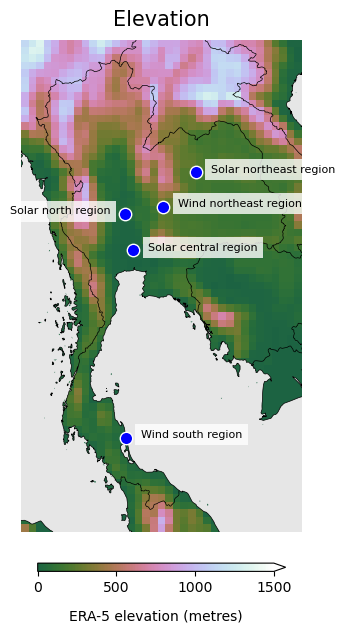

<Figure size 640x480 with 0 Axes>

In [33]:
points = {
    "solar_central_region": (14.168229, 100.553357),
    "solar_north_region": (15.368733, 100.298725),
    "solar_northeast_region": (16.75106275, 102.6180582),
    "wind_northeast_region": (15.606682, 101.548846),
    "wind_south_region": (7.995049, 100.317851),
}
    
fig, ax = plt.subplots(figsize=(4, 8), subplot_kw={'projection': ccrs.PlateCarree()})
contour = ERA5_topo.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), vmin=0, vmax=1500, cmap=mcolors.LinearSegmentedColormap.from_list('trunc', plt.get_cmap('cubehelix')(np.linspace(5/17, 1, 256))), add_colorbar=False)
cbar = plt.colorbar(contour, ax=ax, orientation='horizontal', extend='max', shrink=0.8, aspect=30, pad=0.05)
cbar.set_label('ERA-5 elevation (metres)', labelpad=10)

for name, (lat, lon) in points.items():
    ax.scatter(lon, lat, color='blue', s=80, edgecolor='white',
               transform=ccrs.PlateCarree(), zorder=20)
    ax.text(lon-3.8 if name == 'solar_north_region' else lon+0.5, lat, name.replace('_',' ').capitalize(), fontsize=8,
            transform=ccrs.PlateCarree(), zorder=20,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
    
ax.set_title("Elevation", size=15, pad=10)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black', zorder=10, alpha=1)
ax.add_feature(cfeature.LAND, linewidth=0.5, edgecolor='black', facecolor='none', zorder=10, alpha=1)
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#e6e6e6', alpha=1)
ax.set_frame_on(False)

# ax.legend(ncol=2, bbox_to_anchor=(0.81, -0.3))
plt.show()
plt.clf()

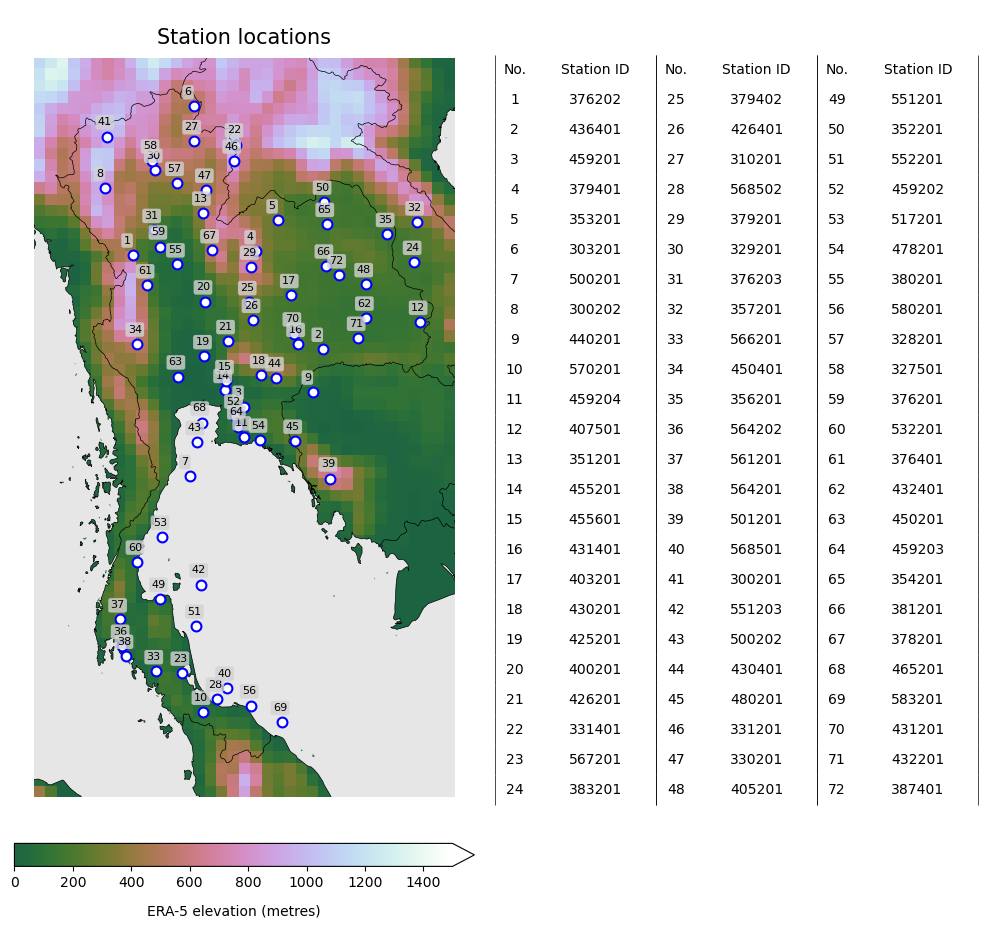

<Figure size 640x480 with 0 Axes>

In [36]:
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

rain_station_latlon_df = pd.read_csv('/g/data/qz03/wp3/data/tmd/obs/station_metadata.csv').dropna()
ERA5_topo = xr.open_dataset('/g/data/rt52/era5/single-levels/reanalysis/z/2025/z_era5_oper_sfc_20251101-20251130.nc').z[0].sel(latitude=slice(domain_dict['thailand']['lat_max'], domain_dict['thailand']['lat_min']), longitude=slice(domain_dict['thailand']['lon_min'], domain_dict['thailand']['lon_max']))/9.80665
fig, ax = plt.subplots(figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
contour = ERA5_topo.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), vmin=0, vmax=1500, cmap=mcolors.LinearSegmentedColormap.from_list('trunc', plt.get_cmap('cubehelix')(np.linspace(5/17, 1, 256))), add_colorbar=False)
cbar = plt.colorbar(contour, ax=ax, orientation='horizontal', extend='max', shrink=0.5, aspect=20, pad=0.05)
cbar.set_label('ERA-5 elevation (metres)', labelpad=10)
ax.set_title("Station locations", size=15, pad=10)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black', zorder=10, alpha=1)
ax.add_feature(cfeature.LAND, linewidth=0.5, edgecolor='black', facecolor='none', zorder=10, alpha=1)
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#e6e6e6', alpha=1)
ax.set_frame_on(False)

station_map = []
for i, (_, row) in enumerate(rain_station_latlon_df.iterrows(), start=1):
    station_map.append([i, int(row['station_id'])])
    ax.text(row['lon']+0.3, row['lat']+0.3, str(i), transform=ccrs.PlateCarree(), fontsize=8, ha='left', va='bottom', zorder=25, color='black', bbox=dict(facecolor='lightgrey', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.2'))

ax.scatter(rain_station_latlon_df['lon']+0.5, rain_station_latlon_df['lat']+0.1, transform=ccrs.PlateCarree(), marker='o', color='white', edgecolor='blue', s=50, linewidth=1.5, label='Rainfall stations', zorder=20)

fig.subplots_adjust(right=0.70)
ax_table = fig.add_axes([0.58, 0.22, 0.28, 0.7])
ax_table.axis('off')

n = len(station_map)
third = (n + 2) // 3

col1 = station_map[:third]
col2 = station_map[third:2*third]
col3 = station_map[2*third:]

max_len = max(len(col1), len(col2), len(col3))
col1 += [["", ""]] * (max_len - len(col1))
col2 += [["", ""]] * (max_len - len(col2))
col3 += [["", ""]] * (max_len - len(col3))

table_data = [col1[i] + col2[i] + col3[i] for i in range(max_len)]

table = ax_table.table(
    cellText=table_data,
    colLabels=['No.', 'Station ID', 'No.', 'Station ID', 'No.', 'Station ID'],
    loc='center',
    cellLoc='center',
    colWidths=[0.1, 0.3, 0.1, 0.3, 0.1, 0.3]
)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_linewidth(0.5)
    
    if c in [0, 2, 4]: 
        cell.visible_edges = 'L'
    else:
        cell.visible_edges = 'R'
        
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(0.9, 1.8)
plt.show()
plt.clf()